### Parte 1: Datamart analítico en BI

##### 1. Definir el proceso de negocio y el grano

1.1 Proceso de negocio

Venta minorista de productos farmacéuticos, cuidado personal, dermocosmética,
suplementos, equipos médicos e insumos en una cadena de boticas con canal físico
y online ("Botica Salud Total").    

1.2 Grano


**Línea de venta**: un producto dentro de una boleta/compra.
Cada fila de Fact_Ventas representa un producto comprado en una transacción
específica (id_venta + id_producto).


##### 2. Identificar dimensiones y hechos

2.1 Tabla de hechos


| Hecho | Descripción |
|---|---|
| Fact_Ventas | Cantidad, precio_unitario, descuento, importe, costo, margen |


2.2 Dimensiones

| Tabla | Descripción | Clave |
|---|---|---|
| Dim_Cliente | Datos del cliente | id_cliente |
| Dim_Producto | Catálogo de productos | id_producto |
| Dim_Tienda | Puntos de venta | id_tienda |
| Dim_Tiempo | Calendario | fecha |
| Dim_Promocion | Ofertas vigentes | id_promocion |


2.3 Diagrama del esquema estrella


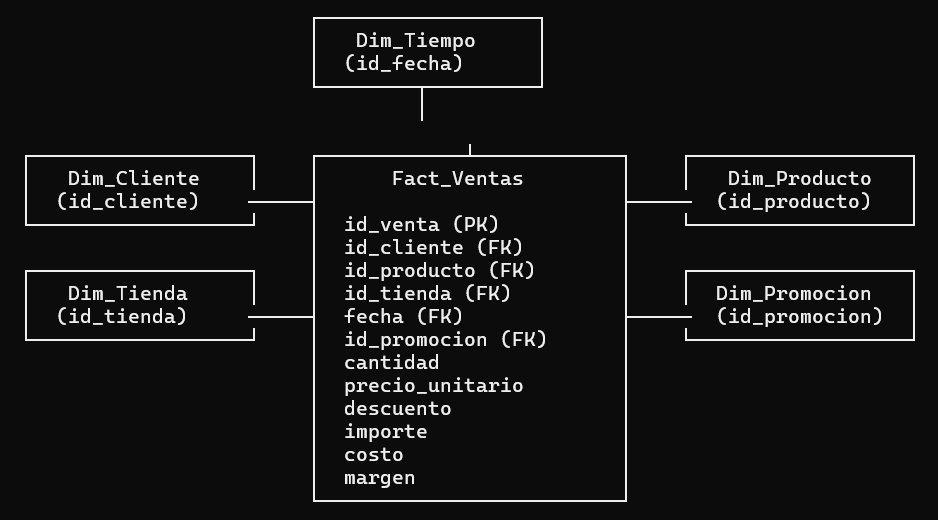

##### 3. Code (imports y carga de datos)

3.1 Importamos los datos

In [19]:
import pandas as pd
import numpy as np
import os

In [20]:

RAW_DIR = "C:/Users/camil/Desktop/ProyectoBI/proyecto-inteligencia-negocios/data/raw"
PROC_DIR = "C:/Users/camil/Desktop/ProyectoBI/proyecto-inteligencia-negocios/data/processed"
os.makedirs(PROC_DIR, exist_ok=True)



In [21]:
# Cargar datos crudos
dim_cliente = pd.read_csv(f"{RAW_DIR}/Dim_Cliente.csv", sep=";", encoding="utf-8")
dim_producto = pd.read_csv(f"{RAW_DIR}/Dim_Producto.csv", sep=";", encoding="utf-8")
dim_tienda = pd.read_csv(f"{RAW_DIR}/Dim_Tienda.csv", sep=";", encoding="utf-8")
dim_tiempo = pd.read_csv(f"{RAW_DIR}/Dim_Tiempo.csv", sep=";", encoding="utf-8")
dim_promocion = pd.read_csv(f"{RAW_DIR}/Dim_Promocion.csv", sep=";", encoding="utf-8")
fact_ventas = pd.read_csv(f"{RAW_DIR}/Fact_Ventas.csv", sep=";", encoding="utf-8")
print("Datos cargados correctamente")

Datos cargados correctamente


In [22]:
print("Datos cargados correctamente")
print(f"Dim_Cliente   : {len(dim_cliente):,} filas")
print(f"Dim_Producto  : {len(dim_producto):,} filas")
print(f"Dim_Tienda    : {len(dim_tienda):,} filas")
print(f"Dim_Tiempo    : {len(dim_tiempo):,} filas")
print(f"Dim_Promocion : {len(dim_promocion):,} filas")
print(f"Fact_Ventas   : {len(fact_ventas):,} filas")

Datos cargados correctamente
Dim_Cliente   : 5,000 filas
Dim_Producto  : 500 filas
Dim_Tienda    : 15 filas
Dim_Tiempo    : 730 filas
Dim_Promocion : 40 filas
Fact_Ventas   : 60,953 filas


3.2 Reporte de calidad inicial de los datos

NULOS

In [23]:
print("=" * 70)
print("REPORTE DE CALIDAD INICIAL NULOS")
print("=" * 70)

tablas = {
    "Dim_Cliente": dim_cliente,
    "Dim_Producto": dim_producto,
    "Dim_Tienda": dim_tienda,
    "Dim_Tiempo": dim_tiempo,
    "Dim_Promocion": dim_promocion,
    "Fact_Ventas": fact_ventas,
}

for nombre, df in tablas.items():
    print(f"\n{'─' * 20}")
    print(f"  TABLA: {nombre}")
    print(f"  Filas: {len(df):,}")
    print(f"{'─' * 20}")
    print(f"  {'Columna':<25} {'Nulos':>8} {'%':>8}")
    print(f"  {'─' * 41}")
    for col in df.columns:
        nulos = df[col].isna().sum()
        pct = nulos / len(df) * 100
        print(f"  {col:<25} {nulos:>8} {pct:>7.2f}%")


REPORTE DE CALIDAD INICIAL NULOS

────────────────────
  TABLA: Dim_Cliente
  Filas: 5,000
────────────────────
  Columna                      Nulos        %
  ─────────────────────────────────────────
  id_cliente                       0    0.00%
  nombre                           0    0.00%
  sexo                             0    0.00%
  fecha_nacimiento                 0    0.00%
  distrito                       322    6.44%
  fecha_alta                       0    0.00%
  segmento_programa                0    0.00%

────────────────────
  TABLA: Dim_Producto
  Filas: 500
────────────────────
  Columna                      Nulos        %
  ─────────────────────────────────────────
  id_producto                      0    0.00%
  nombre                           0    0.00%
  categoria                       31    6.20%
  subcategoria                     0    0.00%
  marca                            0    0.00%
  precio_lista                     0    0.00%
  costo                         

DUPLICADOS

In [24]:
print("  Duplicados por tabla:")
print(f"  {'─' * 38}")
for nombre, df in tablas.items():
    dup = df.duplicated().sum()
    print(f"  {nombre:<25} {dup:>8,}")

  Duplicados por tabla:
  ──────────────────────────────────────
  Dim_Cliente                      0
  Dim_Producto                     0
  Dim_Tienda                       0
  Dim_Tiempo                       0
  Dim_Promocion                    0
  Fact_Ventas                    953


CLAVES HUERFANAS

In [25]:
print("  Claves huérfanas (id_producto en Fact_Ventas sin referencia en Dim_Producto):")
id_productos_validos = set(dim_producto["id_producto"])
huerfanas = fact_ventas[~fact_ventas["id_producto"].isin(id_productos_validos)]
print(f"  {'─' * 50}")
print(f"  Cantidad: {len(huerfanas):,}")
print(f"  Porcentaje: {len(huerfanas)/len(fact_ventas)*100:.2f}%")
if len(huerfanas) > 0:
    print(f"  IDs huérfanos ejemplo: {huerfanas['id_producto'].unique()[:10]}")

  Claves huérfanas (id_producto en Fact_Ventas sin referencia en Dim_Producto):
  ──────────────────────────────────────────────────
  Cantidad: 305
  Porcentaje: 0.50%
  IDs huérfanos ejemplo: [1503 1598 1569 1559 1573 1544 1543 1584 1525 1532]


##### 4. ETL

4.1  Estandarización de fechas

In [26]:
print("=" * 70)
print("4.1 ESTANDARIZACIÓN DE FECHAS")
print("=" * 70)

# Limpiar texto español de fechas
def limpiar_fechas(serie):
    meses = {'enero':'01','febrero':'02','marzo':'03','abril':'04',
             'mayo':'05','junio':'06','julio':'07','agosto':'08',
             'septiembre':'09','octubre':'10','noviembre':'11','diciembre':'12'}
    s = serie.astype(str).str.strip()
    for m, n in meses.items():
        s = s.str.replace(m, n, regex=False)
    s = s.str.replace(r'\s+de\s+', '/', regex=True)
    s = s.str.replace(r'\s+', '', regex=True)

    result = pd.Series([pd.NaT] * len(s), index=s.index)
    mask_iso = s.str.match(r'^\d{4}-\d{2}-\d{2}$', na=False)
    result[mask_iso] = pd.to_datetime(s[mask_iso], format='%Y-%m-%d', errors='coerce')
    mask_local = s.str.match(r'^\d{1,2}/\d{1,2}/\d{4}$', na=False)
    result[mask_local] = pd.to_datetime(s[mask_local], format='%d/%m/%Y', errors='coerce')
    return result

# APLICAR LA FUNCIÓN A LAS 3 COLUMNAS DE FECHA
fact_ventas["fecha"] = limpiar_fechas(fact_ventas["fecha"])
dim_cliente["fecha_nacimiento"] = limpiar_fechas(dim_cliente["fecha_nacimiento"])
dim_cliente["fecha_alta"] = limpiar_fechas(dim_cliente["fecha_alta"])

print(f"Fechas nulas: fact={fact_ventas['fecha'].isna().sum()}, "
      f"nac={dim_cliente['fecha_nacimiento'].isna().sum()}, "
      f"alta={dim_cliente['fecha_alta'].isna().sum()}")




4.1 ESTANDARIZACIÓN DE FECHAS
Fechas nulas: fact=0, nac=0, alta=0


4.2 Normalización de texto/categorías

In [27]:
print("=" * 70)
print("4.2 NORMALIZACIÓN DE TEXTO / CATEGORÍAS")
print("=" * 70)

homologacion = {
    "MEDICAMENTOS": "Medicamentos",
    "CUIDADO PERSONAL": "Cuidado Personal",
    "DERMOCOSMÉTICA": "Dermocosmética",
    "SUPLEMENTOS Y VITAMINAS": "Suplementos y Vitaminas",
    "CUIDADO DEL BEBÉ": "Cuidado del Bebé",
    "EQUIPOS MÉDICOS": "Equipos Médicos",
    "INSUMOS MÉDICOS": "Insumos Médicos",
}

cats_antes = dim_producto["categoria"].nunique()
dim_producto["categoria"] = (
    dim_producto["categoria"]
    .str.strip()
    .str.upper()
    .map(homologacion)
    .fillna("Sin Categoría")
)
cats_despues = dim_producto["categoria"].nunique()
print(f"Categorías únicas: {cats_antes} -> {cats_despues}")
print(f"Categorías finales:\n{dim_producto['categoria'].value_counts()}")

4.2 NORMALIZACIÓN DE TEXTO / CATEGORÍAS
Categorías únicas: 35 -> 8
Categorías finales:
categoria
Cuidado Personal           69
Dermocosmética             69
Suplementos y Vitaminas    68
Cuidado del Bebé           68
Equipos Médicos            66
Medicamentos               65
Insumos Médicos            64
Sin Categoría              31
Name: count, dtype: int64


4.3 Tratamiento de nulos

In [28]:
print("=" * 70)
print("4.3 TRATAMIENTO DE NULOS")
print("=" * 70)

# Dim_Cliente - distrito
nulos_distrito = dim_cliente["distrito"].isna().sum()
dim_cliente["distrito"] = dim_cliente["distrito"].fillna("Sin Especificar")
print(f"Dim_Cliente - distrito: {nulos_distrito} nulos -> 'Sin Especificar'")

# Fact_Ventas - descuento
nulos_descuento = fact_ventas["descuento"].isna().sum()
fact_ventas["descuento"] = fact_ventas["descuento"].fillna(0.0)
print(f"Fact_Ventas - descuento: {nulos_descuento} nulos -> 0.0")

# Nota: id_promocion con nulos NO se trata (es válido: venta sin promoción)
nulos_promo = fact_ventas["id_promocion"].isna().sum()
print(f"Fact_Ventas - id_promocion: {nulos_promo} nulos -> No se tratan (lógica de negocio válida)")

4.3 TRATAMIENTO DE NULOS
Dim_Cliente - distrito: 322 nulos -> 'Sin Especificar'
Fact_Ventas - descuento: 3269 nulos -> 0.0
Fact_Ventas - id_promocion: 36761 nulos -> No se tratan (lógica de negocio válida)


4.4 Eliminación de duplicados

In [29]:
print("=" * 70)
print("4.4 ELIMINACIÓN DE DUPLICADOS")
print("=" * 70)

dup_antes = fact_ventas.duplicated().sum()
fact_ventas = fact_ventas.drop_duplicates()
print(f"Duplicados eliminados: {dup_antes}")
print(f"Filas en Fact_Ventas después: {len(fact_ventas):,}")

4.4 ELIMINACIÓN DE DUPLICADOS
Duplicados eliminados: 953
Filas en Fact_Ventas después: 60,000


4.5 Eliminación de claves huérfanas

In [30]:
print("=" * 70)
print("4.5 ELIMINACIÓN DE CLAVES HUÉRFANAS")
print("=" * 70)

id_productos_validos = set(dim_producto["id_producto"])
huerfanas_antes = (~fact_ventas["id_producto"].isin(id_productos_validos)).sum()
fact_ventas = fact_ventas[fact_ventas["id_producto"].isin(id_productos_validos)]
print(f"Claves huérfanas eliminadas: {huerfanas_antes}")
print(f"Filas en Fact_Ventas después: {len(fact_ventas):,}")

4.5 ELIMINACIÓN DE CLAVES HUÉRFANAS
Claves huérfanas eliminadas: 300
Filas en Fact_Ventas después: 59,700


4.6 Tratamiento de outliers

In [31]:
print("=" * 70)
print("4.6 TRATAMIENTO DE OUTLIERS (VALOR AGREGADO)")
print("=" * 70)

# Outliers en cantidad (>100) -> mediana
mediana_cant = fact_ventas[fact_ventas["cantidad"] <= 100]["cantidad"].median()
outliers_cant = (fact_ventas["cantidad"] > 100).sum()
fact_ventas.loc[fact_ventas["cantidad"] > 100, "cantidad"] = mediana_cant
print(f"Cantidad - outliers corregidos: {outliers_cant} (→ mediana {mediana_cant})")

# Outliers en precio_unitario (<1 o >1000) -> precio_lista
precio_ref = dim_producto.set_index("id_producto")["precio_lista"].to_dict()
mask_precio = (fact_ventas["precio_unitario"] < 1) | (fact_ventas["precio_unitario"] > 1000)
outliers_precio = mask_precio.sum()
fact_ventas.loc[mask_precio, "precio_unitario"] = fact_ventas.loc[mask_precio, "id_producto"].map(precio_ref)
print(f"Precio - outliers corregidos: {outliers_precio} (→ precio_lista de referencia)")

4.6 TRATAMIENTO DE OUTLIERS (VALOR AGREGADO)
Cantidad - outliers corregidos: 240 (→ mediana 1.0)
Precio - outliers corregidos: 240 (→ precio_lista de referencia)


##### 5. Derivación de métricas calculadas

In [32]:
print("=" * 70)
print("5. DERIVACIÓN DE MÉTRICAS")
print("=" * 70)

fact_ventas["importe"] = (fact_ventas["cantidad"] * fact_ventas["precio_unitario"]) - fact_ventas["descuento"]

fact_ventas = fact_ventas.merge(
    dim_producto[["id_producto", "costo"]], on="id_producto", how="left"
)
fact_ventas["costo"] = fact_ventas["cantidad"] * fact_ventas["costo"]
fact_ventas["margen"] = fact_ventas["importe"] - fact_ventas["costo"]

print(f"Importe total: S/ {fact_ventas['importe'].sum():,.2f}")
print(f"Costo total: S/ {fact_ventas['costo'].sum():,.2f}")
print(f"Margen total: S/ {fact_ventas['margen'].sum():,.2f}")
print(f"Ticket promedio: S/ {fact_ventas['importe'].sum() / fact_ventas['id_venta'].nunique():,.2f}")

5. DERIVACIÓN DE MÉTRICAS
Importe total: S/ 4,453,561.59
Costo total: S/ 2,620,576.32
Margen total: S/ 1,832,985.27
Ticket promedio: S/ 74.60


##### 6. Exportar tablas limpias a data/processed/

In [33]:
print("=" * 70)
print("6. EXPORTAR TABLAS LIMPIAS")
print("=" * 70)

import os

# Limpiar CSV anteriores
for f in os.listdir(PROC_DIR):
    if f.endswith(".csv"):
        os.remove(os.path.join(PROC_DIR, f))

# Exportar dimensiones
dim_cliente.to_csv(f"{PROC_DIR}/Dim_Cliente.csv", sep=";", encoding="utf-8", index=False)
dim_producto.to_csv(f"{PROC_DIR}/Dim_Producto.csv", sep=";", encoding="utf-8", index=False)
dim_tienda.to_csv(f"{PROC_DIR}/Dim_Tienda.csv", sep=";", encoding="utf-8", index=False)
dim_tiempo.to_csv(f"{PROC_DIR}/Dim_Tiempo.csv", sep=";", encoding="utf-8", index=False)
dim_promocion.to_csv(f"{PROC_DIR}/Dim_Promocion.csv", sep=";", encoding="utf-8", index=False)

cols_fact = [
    "id_venta", "fecha", "id_cliente", "id_producto", "id_tienda",
    "id_promocion", "cantidad", "precio_unitario", "descuento",
    "importe", "costo", "margen"
]
fact_ventas[cols_fact].to_csv(f"{PROC_DIR}/Fact_Ventas.csv", sep=";", encoding="utf-8", index=False)

print("Tablas exportadas correctamente:")
for f in sorted(os.listdir(PROC_DIR)):
    if f.endswith(".csv"):
        print(f"  - {f}")

6. EXPORTAR TABLAS LIMPIAS
Tablas exportadas correctamente:
  - Dim_Cliente.csv
  - Dim_Producto.csv
  - Dim_Promocion.csv
  - Dim_Tiempo.csv
  - Dim_Tienda.csv
  - Fact_Ventas.csv


##### 7. Diccionario de datos y diagrama estrella

7.1 Diagrama del esquema estrella

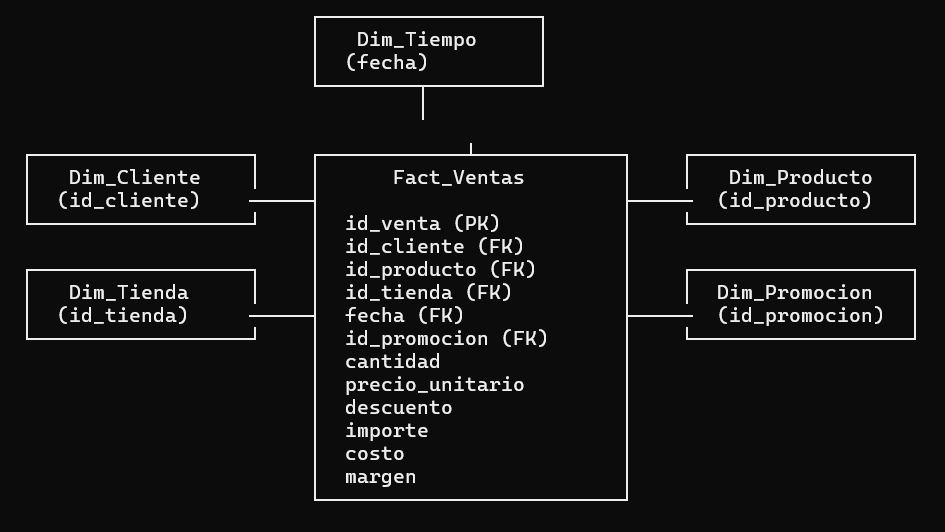

7.2 Diccionario de datos

In [34]:
print("=" * 70)
print("7. DICCIONARIO DE DATOS")
print("=" * 70)

diccionario = pd.DataFrame([
    ("Dim_Cliente", "id_cliente", "int", "PK", "Identificador único del cliente"),
    ("Dim_Cliente", "nombre", "str", "", "Nombre completo del cliente"),
    ("Dim_Cliente", "sexo", "str", "", "Sexo (M/F)"),
    ("Dim_Cliente", "fecha_nacimiento", "date", "", "Fecha de nacimiento"),
    ("Dim_Cliente", "distrito", "str", "", "Distrito de residencia"),
    ("Dim_Cliente", "fecha_alta", "date", "", "Fecha de alta en el programa"),
    ("Dim_Cliente", "segmento_programa", "str", "", "Segmento (Oro/Plata/Bronce/Sin Programa)"),
    ("Dim_Producto", "id_producto", "int", "PK", "Identificador único del producto"),
    ("Dim_Producto", "nombre", "str", "", "Nombre del producto"),
    ("Dim_Producto", "categoria", "str", "", "Categoría del producto"),
    ("Dim_Producto", "subcategoria", "str", "", "Subcategoría"),
    ("Dim_Producto", "marca", "str", "", "Marca"),
    ("Dim_Producto", "precio_lista", "float", "", "Precio de lista"),
    ("Dim_Producto", "costo", "float", "", "Costo unitario"),
    ("Dim_Tienda", "id_tienda", "int", "PK", "Identificador único de tienda"),
    ("Dim_Tienda", "nombre", "str", "", "Nombre comercial"),
    ("Dim_Tienda", "canal", "str", "", "Canal (fisico/online)"),
    ("Dim_Tienda", "region", "str", "", "Región geográfica"),
    ("Dim_Tienda", "ciudad", "str", "", "Ciudad"),
    ("Dim_Tiempo", "fecha", "date", "PK", "Fecha"),
    ("Dim_Tiempo", "dia", "int", "", "Día del mes (1-31)"),
    ("Dim_Tiempo", "mes", "int", "", "Mes (1-12)"),
    ("Dim_Tiempo", "trimestre", "int", "", "Trimestre (1-4)"),
    ("Dim_Tiempo", "anio", "int", "", "Año"),
    ("Dim_Tiempo", "dia_semana", "str", "", "Nombre del día de la semana"),
    ("Dim_Tiempo", "es_feriado", "bool", "", "Indica si es feriado"),
    ("Dim_Promocion", "id_promocion", "int", "PK", "Identificador único de promoción"),
    ("Dim_Promocion", "nombre", "str", "", "Nombre de la promoción"),
    ("Dim_Promocion", "tipo", "str", "", "Tipo de promoción"),
    ("Dim_Promocion", "descuento_pct", "float", "", "Porcentaje de descuento"),
    ("Dim_Promocion", "fecha_inicio", "date", "", "Inicio de vigencia"),
    ("Dim_Promocion", "fecha_fin", "date", "", "Fin de vigencia"),
    ("Fact_Ventas", "id_venta", "int", "PK", "Identificador único de venta"),
    ("Fact_Ventas", "fecha", "date", "FK", "Fecha de venta -> Dim_Tiempo"),
    ("Fact_Ventas", "id_cliente", "int", "FK", "Cliente -> Dim_Cliente"),
    ("Fact_Ventas", "id_producto", "int", "FK", "Producto -> Dim_Producto"),
    ("Fact_Ventas", "id_tienda", "int", "FK", "Tienda -> Dim_Tienda"),
    ("Fact_Ventas", "id_promocion", "float", "FK", "Promoción -> Dim_Promocion (NaN = sin promo)"),
    ("Fact_Ventas", "cantidad", "int", "", "Cantidad vendida"),
    ("Fact_Ventas", "precio_unitario", "float", "", "Precio unitario aplicado"),
    ("Fact_Ventas", "descuento", "float", "", "Monto de descuento en soles"),
    ("Fact_Ventas", "importe", "float", "", "(cantidad * precio_unitario) - descuento"),
    ("Fact_Ventas", "costo", "float", "", "cantidad * costo_unitario"),
    ("Fact_Ventas", "margen", "float", "", "importe - costo"),
], columns=["Tabla", "Campo", "Tipo", "Clave", "Descripción"])

diccionario.to_csv(f"{PROC_DIR}/diccionario_datos.csv", sep=";", encoding="utf-8", index=False)
display(diccionario)

7. DICCIONARIO DE DATOS


,Tabla,Campo,Tipo,Clave,Descripción
0,Dim_Cliente,id_cliente,int,PK,Identificador único del cliente
1,Dim_Cliente,nombre,str,,Nombre completo del cliente
2,Dim_Cliente,sexo,str,,Sexo (M/F)
3,Dim_Cliente,fecha_nacimiento,date,,Fecha de nacimiento
4,Dim_Cliente,distrito,str,,Distrito de residencia
5,Dim_Cliente,fecha_alta,date,,Fecha de alta en el programa
6,Dim_Cliente,segmento_programa,str,,Segmento (Oro/Plata/Bronce/Sin Programa)
7,Dim_Producto,id_producto,int,PK,Identificador único del producto
8,Dim_Producto,nombre,str,,Nombre del producto
9,Dim_Producto,categoria,str,,Categoría del producto
